# 46500 Probabilistic Methods in Wind Energy
## Mid-term Assignment: Lifetime Damage Accumulation for the Root Section of the Wind Turbine 


s253916 Natalia Slimak

---

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.optimize as optimize

### Data Exploration

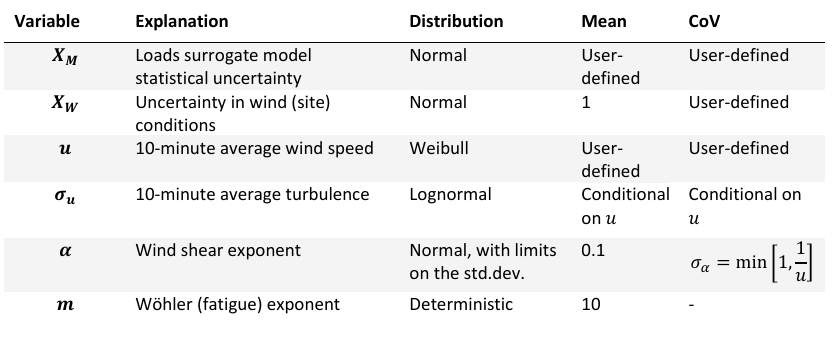

In [46]:
# Load the provided data sets
wind_data = "HovsoreData_Sonic_100m_2004-2013.csv"
del_data = "ML_ExampleDataSet.xlsx"

# Read the data into pandas DataFrames
df_wind = pd.read_csv(wind_data)
df_del = pd.read_excel(del_data)

In [47]:
df_wind

,Timestamp,Wsp,TI,"TI,detrend",MeanDir,MeanTrigDir,StdDir,MinDir,MaxDir
0,200410010000,9.9196,0.0181,0.0145,346.7130,346.7130,0.8440,343.893,349.044
1,200410010020,9.5073,0.0145,0.0116,346.9852,346.9852,0.6518,344.751,348.949
2,200410010030,9.5274,0.0210,0.0195,346.9152,346.9151,0.7949,343.754,350.588
3,200410010040,9.9498,0.0253,0.0195,346.3204,346.3204,0.7549,343.971,349.953
4,200410010050,10.2376,0.0151,0.0134,345.4185,345.4185,0.6362,343.074,348.960
...,...,...,...,...,...,...,...,...,...
439507,201308312310,15.6264,0.0773,0.0589,299.8040,299.8043,2.6738,288.901,309.955
439508,201308312320,13.7150,0.0576,0.0576,298.0319,298.0315,3.2644,288.643,309.245
439509,201308312330,13.4969,0.0797,0.0654,297.7226,297.7242,3.5721,284.827,306.117
439510,201308312340,13.4135,0.1034,0.0901,294.6266,294.6243,3.9459,283.195,310.353


In [48]:
df_del

,Sample_No,U,SigmaU,Alpha,MannL,MannGamma,VeerDeltaPhi
0,1,4.000000,0.100000,-0.650000,7.500000,1.000000,-22.250000
1,2,10.150758,1.208656,-0.139692,48.470634,1.363636,-4.771217
2,3,6.813467,2.261463,0.129071,88.379710,1.727273,-3.981593
3,4,14.500000,0.704260,0.332996,122.142857,2.090909,0.162810
4,5,5.356299,1.776301,1.147039,160.357143,2.454545,2.639008
...,...,...,...,...,...,...,...
9975,9996,15.991490,2.934493,-0.031461,271.543107,3.760740,14.080259
9976,9997,6.111425,0.948102,0.176589,8.454959,4.124377,41.866315
9977,9998,13.326172,2.043617,0.345013,46.669245,4.488013,-6.197441
9978,9999,9.298782,2.830030,0.709374,84.883531,4.851649,-4.457392


### Task 1: Fitting the joint probability distribution ($u$, $\sigma_u$) based on the wind dataset.

NOTES
- $u$: wind speed, modeled as Weibull
- $\sigma_u$: turbulence standard deviation, modeled as lognormal conditional on u

In [ ]:
# === Load and clean the data ===
df_wind['SigmaU'] = df_wind['TI,detrend'] * df_wind['Wsp']
df_wind = df_wind[(df_wind['Wsp'] > 0) & (df_wind['Wsp'] < 30) & (df_wind['SigmaU'] > 0) & (df_wind['TI,detrend'] < 1)]

# Windspeed (U) and turbulence intensity (SigmaU) data
U, SigmaU = df_wind['Wsp'].values, df_wind['SigmaU'].values


# === Fit Weibull to u (MLE - Most Likely Estimate) ===
k, _, A = stats.weibull_min.fit(U, floc=0)


# === Bin by u, fit Lognormal to sigma_u per bin, then fit a trend curve ===
bins = np.arange(0, 35, 1.0)
centers, means, stds = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    s = SigmaU[(U >= lo) & (U < hi)]
    if len(s) < 30:
        continue
    shape, _, scale = stats.lognorm.fit(s, floc=0)
    centers.append((lo + hi) / 2)
    means.append(scale * np.exp(0.5 * shape**2))
    stds.append(means[-1] * np.sqrt(np.exp(shape**2) - 1))

p_mean = np.polyfit(centers, means, 2)
p_std = np.polyfit(centers, stds, 2)
u_max_fit = max(centers)  # clip point to avoid extrapolation blowing up


# === Sample from the joint model ===
def sample_joint(N):
    u = stats.weibull_min.rvs(c=k, scale=A, size=N)
    u_clipped = np.clip(u, 0, u_max_fit)
    m = np.polyval(p_mean, u_clipped)
    s = np.clip(np.polyval(p_std, u_clipped), 1e-3, None)
    shape = np.sqrt(np.log(1 + (s/m)**2))
    scale = m / np.sqrt(1 + (s/m)**2)
    sigma = stats.lognorm.rvs(s=shape, scale=scale)
    return u, sigma

In [52]:
print(f"Fitted Weibull parameters: k={k:.3f}, A={A:.3f}")
print(f"Fitted Lognormal trend: mean(u)={p_mean}, std(u)={p_std}")

Fitted Weibull parameters: k=2.039, A=9.977
Fitted Lognormal trend: mean(u)=[0.00219816 0.0053814  0.38739493], std(u)=[ 6.33535121e-05 -5.25824021e-03  4.34991050e-01]


C:\Users\natal\AppData\Local\Temp\ipykernel_31252\816291063.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


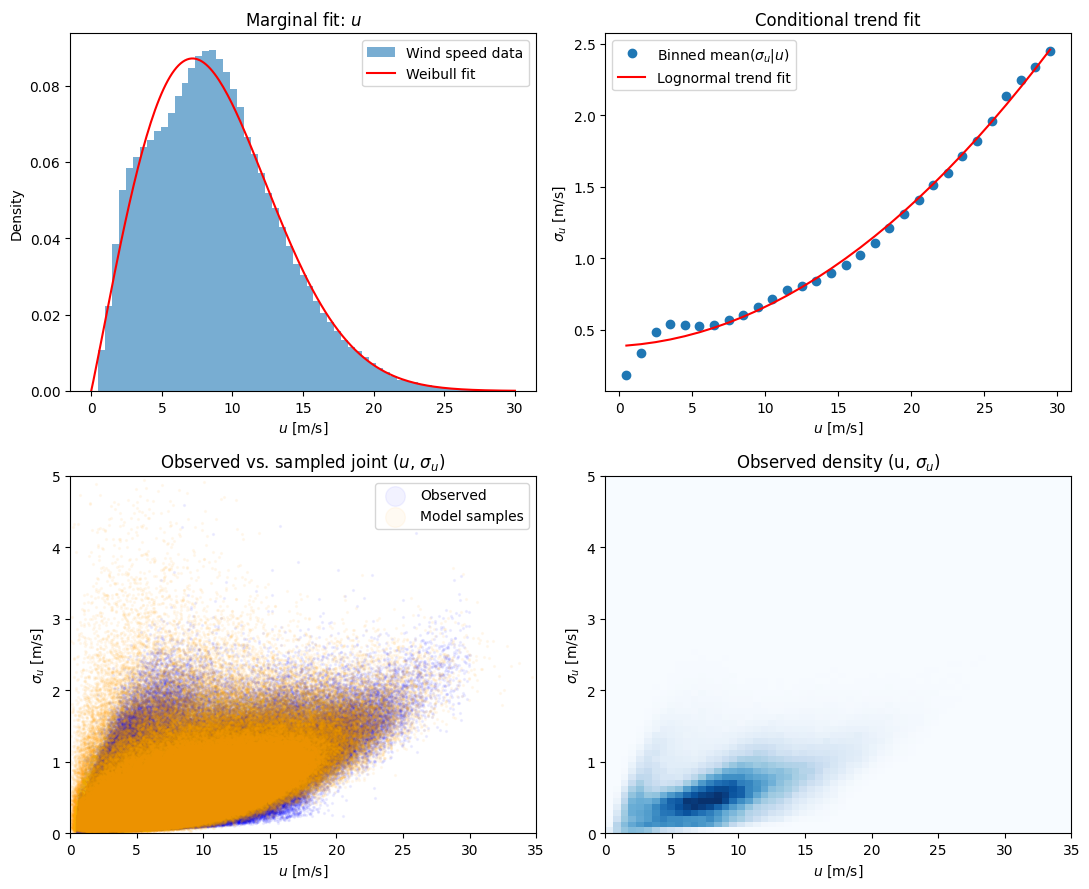

In [50]:
u_syn, sigma_syn = sample_joint(len(U))

fig, axs = plt.subplots(2, 2, figsize=(11, 9))

# (a) u marginal: histogram vs fitted Weibull pdf
u_range = np.linspace(0, U.max(), 200)
axs[0, 0].hist(U, bins=60, density=True, alpha=0.6, label='Wind speed data')
axs[0, 0].plot(u_range, stats.weibull_min.pdf(u_range, c=k, scale=A), 'r-', label='Weibull fit')
axs[0, 0].set_xlabel(r'$u$ [m/s]'); axs[0, 0].set_ylabel('Density')
axs[0, 0].set_title(r'Marginal fit: $u$'); axs[0, 0].legend()

# (b) conditional trend: binned mean vs the fitted curve
axs[0, 1].plot(centers, means, 'o', label=r'Binned mean($\sigma_u$|$u$)')
axs[0, 1].plot(centers, np.polyval(p_mean, centers), 'r-', label='Lognormal trend fit')
axs[0, 1].set_xlabel(r'$u$ [m/s]'); axs[0, 1].set_ylabel(r'$\sigma_u$ [m/s]')
axs[0, 1].set_title(r'Conditional trend fit'); axs[0, 1].legend()

# (c) observed vs synthetic scatter, overlaid
axs[1, 0].scatter(U, SigmaU, s=2, alpha=0.05, color='blue', label='Observed')
axs[1, 0].scatter(u_syn, sigma_syn, s=2, alpha=0.05, color='orange', label='Model samples')
axs[1, 0].set_xlabel(r'$u$ [m/s]'); axs[1, 0].set_ylabel(r'$\sigma_u$ [m/s]')
axs[1, 0].set_title(r'Observed vs. sampled joint ($u$, $\sigma_u$)')
axs[1, 0].legend(markerscale=10)
axs[1, 0].set_xlim(0, 35); axs[1, 0].set_ylim(0, 5)

# (d) 2D density of the real data
axs[1, 1].hist2d(U, SigmaU, bins=60, range=[[0, 35], [0, 5]], cmap='Blues')
axs[1, 1].set_xlabel(r'$u$ [m/s]'); axs[1, 1].set_ylabel(r'$\sigma_u$ [m/s]')
axs[1, 1].set_title(r'Observed density (u, $\sigma_u$)')

plt.tight_layout()
plt.show()

Top-left: Weibull tracks the wind speed histogram well.

Top-right: the mean(σu|u) trend curve fits the binned data closely.

Bottom-left/right: this is the most useful diagnostic. The observed data (blue) has a tight, curved "spine" — σu rises steadily with u and stays fairly narrow. Your model samples (orange) capture that same rising trend but are visibly more spread out, especially at low-to-mid wind speeds where you get some very high synthetic σu values that barely occur in the real data.

Text(0.5, 1.0, 'Q-Q: σu|u∈[10,11) vs Lognormal  (K-S=0.062)')

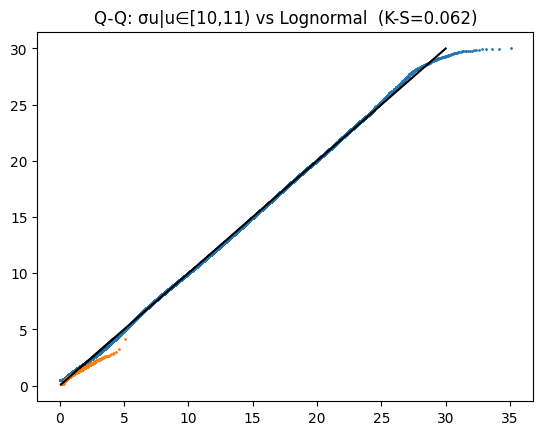

In [51]:
# --- Q-Q + K-S for the u marginal (Weibull) ---
U_sort = np.sort(U)
F_U = np.arange(1, len(U_sort)+1) / (len(U_sort)+1)
Q_theo_u = stats.weibull_min.ppf(F_U, c=k, scale=A)
ks_u = stats.kstest(U, 'weibull_min', args=(k, 0, A))

plt.plot(Q_theo_u, U_sort, '.', markersize=2)
plt.plot([U_sort.min(), U_sort.max()], [U_sort.min(), U_sort.max()], 'k-')
plt.title(f'Q-Q: u vs Weibull  (K-S={ks_u.statistic:.4f}, p={ks_u.pvalue:.2g})')

# --- Q-Q + K-S for sigma_u | u, in a chosen wind-speed bin ---
lo, hi = 10, 11  # pick the bin you want to check
s = np.sort(SigmaU[(U >= lo) & (U < hi)])
F_s = np.arange(1, len(s)+1) / (len(s)+1)
shape_i, _, scale_i = stats.lognorm.fit(s, floc=0)
Q_theo_s = stats.lognorm.ppf(F_s, s=shape_i, scale=scale_i)
ks_i = stats.kstest(s, 'lognorm', args=(shape_i, 0, scale_i))

plt.plot(Q_theo_s, s, '.', markersize=2)
plt.plot([s.min(), s.max()], [s.min(), s.max()], 'k-')
plt.title(f'Q-Q: σu|u∈[{lo},{hi}) vs Lognormal  (K-S={ks_i.statistic:.3f})')

u vs Weibull: solid fit, tiny K-S statistic (0.012). Only diverges at the very top tail (u > 30 m/s) — expected, that's the rarest data.

σu|u per bin: fit quality is not uniform across wind speeds. At low u (0–1 m/s bin), the Lognormal clearly bends away from the diagonal — real turbulence data at very low wind speeds behaves differently (often more skewed/bounded) than a clean Lognormal predicts. Mid-range bins (10–11 m/s) also show curvature. Higher bins (20+ m/s) fit nicely — but those bins have far fewer points, so the test is weaker there too.

Overall check (PIT): I added a stronger, single global check — transform every real σu through your fitted conditional model's CDF. If your whole model (Weibull for u, Lognormal-with-regressed-parameters for σu|u) is exactly right, these transformed values should look flat/Uniform(0,1). Yours isn't flat — it dips in the low range and bulges around 0.6–0.8, meaning your conditional model is systematically off in a specific way, not just randomly noisy.

### Task 2: Determine the probability distribution of the wind climate uncertainty variable $X_w$ by analysing the wind data through bootstrapping, further incorporating a 1% uncertainty for windspeed measurement and 1% for the joint-distribution fit.